In [7]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/Licenta/lfw50"

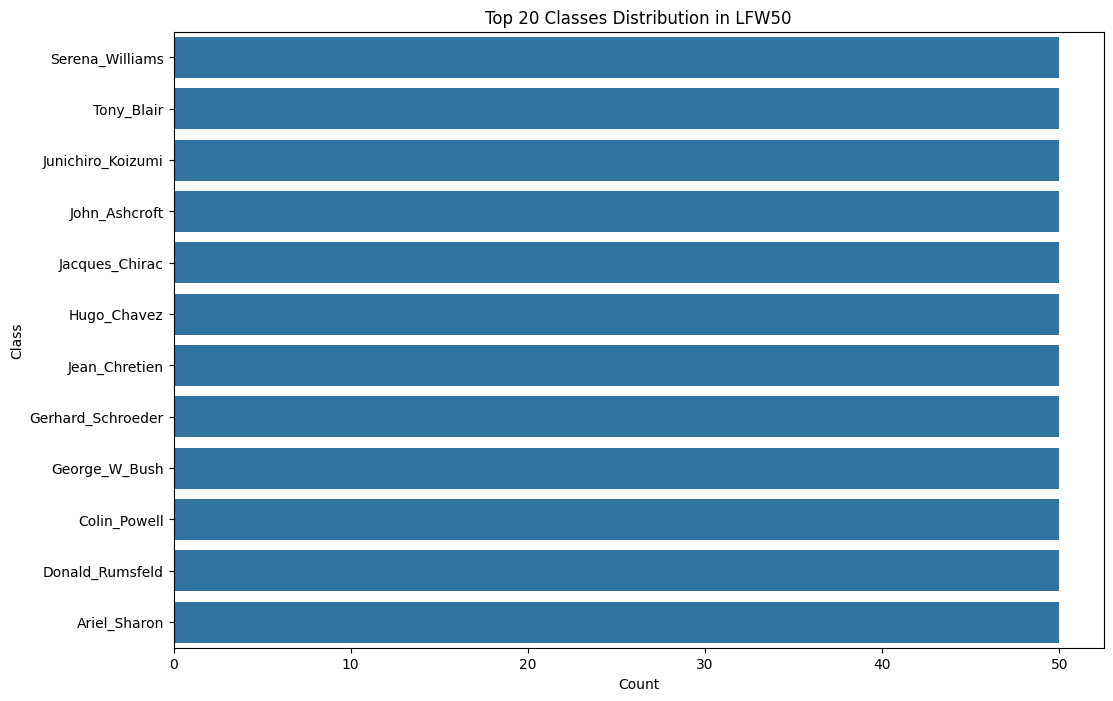

In [8]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Count images per class
classes = os.listdir(data_dir)
counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes if os.path.isdir(os.path.join(data_dir, cls))}
df_dist = pd.DataFrame(list(counts.items()), columns=['Class', 'Count']).sort_values(by='Count', ascending=False)

# Plot distribution
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Class', data=df_dist.head(20))
plt.title('Top 20 Classes Distribution in LFW50')
plt.show()

In [9]:
import tensorflow as tf

# Using the directory defined in the first cell
img_height, img_width = 224, 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
print(f"Classes: {class_names}")

Found 600 files belonging to 12 classes.
Using 480 files for training.
Found 600 files belonging to 12 classes.
Using 120 files for validation.
Classes: ['Ariel_Sharon', 'Colin_Powell', 'Donald_Rumsfeld', 'George_W_Bush', 'Gerhard_Schroeder', 'Hugo_Chavez', 'Jacques_Chirac', 'Jean_Chretien', 'John_Ashcroft', 'Junichiro_Koizumi', 'Serena_Williams', 'Tony_Blair']


In [10]:
# Switching model to TensorFlow Keras to match the new data loading method
num_classes = len(class_names)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze base layers

# Renaming the model as requested
PersonCNN_ResNet50_lfw50 = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

PersonCNN_ResNet50_lfw50.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

PersonCNN_ResNet50_lfw50.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 12)             │        24,588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,612,300 (90.07 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# 1. Unfreeze the top layers of the base model for fine-tuning
base_model.trainable = True
# We'll freeze all layers except the last 15
fine_tune_at = len(base_model.layers) - 15
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 2. Re-build with the enhanced head
PersonCNN_ResNet50_lfw50 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# 3. Use a very low learning rate for fine-tuning to avoid wrecking pre-trained weights
initial_learning_rate = 1e-5

PersonCNN_ResNet50_lfw50.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 4. Add a Learning Rate Scheduler to the callbacks in the next cell
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Model configured for Fine-Tuning (Last 15 layers unfrozen).")
print(f"Initial fine-tuning learning rate: {initial_learning_rate}")

Model configured for Fine-Tuning (Last 15 layers unfrozen).
Initial fine-tuning learning rate: 1e-05


### Next Step: Fine-Tuning
If augmentation isn't enough, we can unfreeze the last few layers of ResNet50:
```python
base_model.trainable = True
# Fine-tune from this layer onwards
fine_tune_at = 140
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with a MUCH smaller learning rate
PersonCNN_ResNet50_lfw50.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
```

In [12]:
# Custom callback to save every N epochs
class PeriodicModelCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath, save_freq_epochs=2):
        super().__init__()
        self.filepath = filepath
        self.save_freq_epochs = save_freq_epochs

    def on_epoch_end(self, epoch, logs=None):
        actual_epoch = epoch + 1
        if actual_epoch % self.save_freq_epochs == 0:
            path = self.filepath.format(epoch=actual_epoch, **logs)
            self.model.save(path)
            print(f"\nEpoch {actual_epoch}: saving model to {path}")

checkpoint_dir = "/content/drive/MyDrive/Colab Notebooks/Licenta/ResNet50_lfw50/Checkpoints"
model_name = "PersonCNN_ResNet50_lfw50_FT"
checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_epoch_{{epoch:02d}}_val_acc_{{val_accuracy:.4f}}.keras")

cp_callback = PeriodicModelCheckpoint(checkpoint_path, save_freq_epochs=2)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# Training with Fine-Tuning and LR Scheduler
history = PersonCNN_ResNet50_lfw50.fit(
    train_ds,
    validation_data=val_ds,
    epochs=230,
    callbacks=[cp_callback, early_stopping, reduce_lr]
)

Epoch 1/230
15/15 ━━━━━━━━━━━━━━━━━━━━ 182s 12s/step - accuracy: 0.0979 - loss: 3.6589 - val_accuracy: 0.0583 - val_loss: 2.7158 - learning_rate: 1.0000e-05
Epoch 2/230
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.0708 - loss: 3.6201
Epoch 2: saving model to /content/drive/MyDrive/Colab Notebooks/Licenta/ResNet50_lfw50/Checkpoints/PersonCNN_ResNet50_lfw50_FT_epoch_02_val_acc_0.0417.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 312ms/step - accuracy: 0.0896 - loss: 3.5275 - val_accuracy: 0.0417 - val_loss: 2.6863 - learning_rate: 1.0000e-05
Epoch 3/230
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - accuracy: 0.0792 - loss: 3.4690 - val_accuracy: 0.0500 - val_loss: 2.6561 - learning_rate: 1.0000e-05
Epoch 4/230
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.1125 - loss: 3.4225
Epoch 4: saving model to /content/drive/MyDrive/Colab Notebooks/Licenta/ResNet50_lfw50/Checkpoints/PersonCNN_ResNet50_lfw50_FT_epoch_04_val_acc_0.0667.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 338ms/step - accuracy: 